In [6]:
import pandas as pd

data = pd.read_csv('../dataset/emi_prediction_dataset.csv')

C:\Users\haris\AppData\Local\Temp\ipykernel_11828\3613047638.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('../dataset/emi_prediction_dataset.csv')


In [2]:
data.columns

Index(['age', 'gender', 'marital_status', 'education', 'monthly_salary',
       'employment_type', 'years_of_employment', 'company_type', 'house_type',
       'monthly_rent', 'family_size', 'dependents', 'school_fees',
       'college_fees', 'travel_expenses', 'groceries_utilities',
       'other_monthly_expenses', 'existing_loans', 'current_emi_amount',
       'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario',
       'requested_amount', 'requested_tenure', 'emi_eligibility',
       'max_monthly_emi'],
      dtype='object')

In [10]:
for col in data.columns:
    print(f"{col}: {data[col].unique()}")

age: [38. 58. 48. 32. 27. 47. 37. 31. 59. 49. 33. 26. 39. 57. 28.]
gender: ['Female' 'Male' 'female' 'male' 'M' 'MALE' 'F' 'FEMALE']
marital_status: ['Married' 'Single']
education: ['Professional' 'Graduate' 'High School' 'Post Graduate' nan]
monthly_salary: ['82600.0' '21500.0' '86100.0' ... '56779.0' '56280.0' '55905.0']
employment_type: ['Private' 'Government' 'Self-employed']
years_of_employment: [ 0.9  7.   5.8  2.2  3.4  5.  36.  12.9  1.9  7.5  3.7  1.3  3.2  0.5
 26.   0.8  4.2  2.6  3.9  9.7  4.7  9.6  1.7  9.4  4.1  1.   7.6 16.
  2.5  1.6 17.1  6.6 12.6  2.3  4.5 11.3 10.   0.7  3.   2.1  2.7  0.6
  8.6  5.9  8.4 12.4  2.8 15.9 10.2  1.2  1.5 14.   1.1  6.5  7.4  7.2
 20.7 17.6 16.6 10.9 20.6 29.7  8.5 10.8 14.2  9.9 24.3  9.1 11.4 11.8
  2.   6.2  6.9  5.2 11.7 18.1  8.2  3.1  3.3  7.1  5.5 10.4  4.   2.4
  8.3  6.1  4.4  8.8  5.6  5.4  4.6 17.8 20.2 22.7 13.6  8.   4.3  2.9
 10.5 13.1 14.1 11.2  4.8 15.7  6.3  5.3 18.9 11.9 21.3  6.4 15.5  3.5
 12.   1.8 13.3  1.4 20.5  8.

In [7]:
data["age"].unique()

array([38.0, 58.0, 48.0, 32.0, 27.0, 47.0, 37.0, 31.0, 59.0, 49.0, 33.0,
       26.0, 39.0, 57.0, 28.0, '58', '38', '48', '32', '27', '37', '48.0',
       '33', '38.0', '49', '27.0', '31', '39', '47', '59', '32.0', '58.0',
       '57', '26', '28', '58.0.0', '39.0', '26.0', '37.0', '38.0.0',
       '32.0.0'], dtype=object)

In [8]:
# cleaning the age column
data["age"] = (
    data["age"]
    .astype(str)
    .str.rsplit('.', n=1).str[0]   # remove last dot and everything after
)
data["age"] = pd.to_numeric(data["age"], errors='coerce')

In [11]:
# cleaning the gender column
data["gender"] = (
    data["gender"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "m": "male",
        "male": "male",
        "f": "female",
        "female": "female"
    })
)

In [13]:
# cleaning the marital_status column
data["marital_status"] = (
    data["marital_status"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace("nan", pd.NA)   # convert string "nan" back to actual missing value
)

In [14]:
# cleaning the education column
data["education"] = (
    data["education"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace("nan", pd.NA)   # convert string "nan" back to actual missing value
)

In [16]:
# cleaning the montly_salary column
data["monthly_salary"] = (
    data["monthly_salary"]
    .astype(str)
    .str.rsplit('.', n=1).str[0]   # remove last dot and everything after
)
data["monthly_salary"] = pd.to_numeric(data["monthly_salary"], errors='coerce')

In [18]:
# cleaning the emplyment_type column
data["employment_type"] = (
    data["employment_type"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace("nan", pd.NA)   # convert string "nan" back to actual missing value
)

In [22]:
# cleaning the years_of_employment column
data["years_of_employment"] = (
    data["years_of_employment"]
    .astype(str)
    .str.rsplit('.', n=1).str[0]   # remove last dot and everything after
)
data["years_of_employment"] = pd.to_numeric(data["years_of_employment"], errors='coerce')

In [26]:
# cleaning the company_type column
data["company_type"] = (
    data["company_type"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace("nan", pd.NA)   # convert string "nan" back to actual missing value
)

In [28]:
# cleaning the house_type column
data["house_type"] = (
    data["house_type"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace("nan", pd.NA)   # convert string "nan" back to actual missing value
)

In [30]:
# cleaning the montly_rent column
data["monthly_rent"] = (
    data["monthly_rent"]
    .astype(str)
    .str.rsplit('.', n=1).str[0]   # remove last dot and everything after
)
data["monthly_rent"] = pd.to_numeric(data["monthly_rent"], errors='coerce')

In [32]:
# cleaning the family_size column
data["family_size"] = (
    data["family_size"]
    .astype(str)
    .str.rsplit('.', n=1).str[0]   # remove last dot and everything after
)
data["family_size"] = pd.to_numeric(data["family_size"], errors='coerce')

In [33]:
# cleaning the dependents column
data["dependents"] = (
    data["dependents"]
    .astype(str)
    .str.rsplit('.', n=1).str[0]   # remove last dot and everything after
)
data["dependents"] = pd.to_numeric(data["dependents"], errors='coerce')

In [37]:
# cleaning the school_fee column
data["school_fees"] = (
    data["school_fees"]
    .astype(str)
    .str.rsplit('.', n=1).str[0]   # remove last dot and everything after
)
data["school_fees"] = pd.to_numeric(data["school_fees"], errors='coerce')

In [39]:
# cleaning the college_fee column
data["college_fees"] = (
    data["college_fees"]
    .astype(str)
    .str.rsplit('.', n=1).str[0]   # remove last dot and everything after
)
data["college_fees"] = pd.to_numeric(data["college_fees"], errors='coerce')

In [41]:
# cleaning the travel_expenses column
data["travel_expenses"] = (
    data["travel_expenses"]
    .astype(str)
    .str.rsplit('.', n=1).str[0]   # remove last dot and everything after
)
data["travel_expenses"] = pd.to_numeric(data["travel_expenses"], errors='coerce')

In [43]:
# cleaning the groceries_utilities column
data["groceries_utilities"] = (
    data["groceries_utilities"]
    .astype(str)
    .str.rsplit('.', n=1).str[0]   # remove last dot and everything after
)
data["groceries_utilities"] = pd.to_numeric(data["groceries_utilities"], errors='coerce')

In [44]:
# cleaning the other_monthly_expenses column
data["other_monthly_expenses"] = (
    data["other_monthly_expenses"]
    .astype(str)
    .str.rsplit('.', n=1).str[0]   # remove last dot and everything after
)
data["other_monthly_expenses"] = pd.to_numeric(data["other_monthly_expenses"], errors='coerce')

In [45]:
# cleaning the existing_loans column
data["existing_loans"] = (data["existing_loans"].astype(str).str.strip().str.lower().replace("nan", pd.NA))

In [46]:
# cleaning the current_emi_amount column
data["current_emi_amount"] = (
    data["current_emi_amount"]
    .astype(str)
    .str.rsplit('.', n=1).str[0]   # remove last dot and everything after
)
data["current_emi_amount"] = pd.to_numeric(data["current_emi_amount"], errors='coerce')

In [56]:
# cleaning the credit_score column
data["credit_score"] = (
    data["credit_score"]
    .astype(str)
    .str.rsplit('.', n=1).str[0]   # remove last dot and everything after
)
data["credit_score"] = pd.to_numeric(data["credit_score"], errors='coerce')
data = data[data["credit_score"].notna() & (data["credit_score"] != 0)]

In [48]:
# cleaning the bank_balance column
data["bank_balance"] = (
    data["bank_balance"]
    .astype(str)
    .str.rsplit('.', n=1).str[0]   # remove last dot and everything after
)
data["bank_balance"] = pd.to_numeric(data["bank_balance"], errors='coerce')

In [49]:
# cleaning the emergency_fund column
data["emergency_fund"] = (
    data["emergency_fund"]
    .astype(str)
    .str.rsplit('.', n=1).str[0]   # remove last dot and everything after
)
data["emergency_fund"] = pd.to_numeric(data["emergency_fund"], errors='coerce')

In [50]:
# cleaning the emi_scenario column
data["emi_scenario"] = (
    data["emi_scenario"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace("nan", pd.NA)   # convert string "nan" back to actual missing value
)

In [51]:
# cleaning the requested_amount column
data["requested_amount"] = (
    data["requested_amount"]
    .astype(str)
    .str.rsplit('.', n=1).str[0]   # remove last dot and everything after
)
data["requested_amount"] = pd.to_numeric(data["requested_amount"], errors='coerce')

In [52]:
# cleaning the requested_tenure column
data["requested_tenure"] = (
    data["requested_tenure"]
    .astype(str)
    .str.rsplit('.', n=1).str[0]   # remove last dot and everything after
)
data["requested_tenure"] = pd.to_numeric(data["requested_tenure"], errors='coerce')

In [53]:
# cleaning the emi_eligibility column
data["emi_eligibility"] = (
    data["emi_eligibility"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace("nan", pd.NA)   # convert string "nan" back to actual missing value
)

In [54]:
# cleaning the max_monthly_emi column
data["max_monthly_emi"] = (
    data["max_monthly_emi"]
    .astype(str)
    .str.rsplit('.', n=1).str[0]   # remove last dot and everything after
)
data["max_monthly_emi"] = pd.to_numeric(data["max_monthly_emi"], errors='coerce')

In [57]:
for col in data.columns:
    print(f"{col}: {data[col].unique()}")

age: [38. 58. 48. 32. 27. 47. 37. 31. 59. 49. 33. 26. 39. 57. 28.]
gender: ['female' 'male']
marital_status: ['married' 'single']
education: ['professional' 'graduate' 'high school' 'post graduate' <NA>]
monthly_salary: [82600. 21500. 86100. ... 56779. 56280. 55905.]
employment_type: ['private' 'government' 'self-employed']
years_of_employment: [ 0  7  5  2  3 36 12  1 26  4  9 16 17  6 11 10  8 15 14 20 29 24 18 22
 13 21 32 25 23 27 33 19 35 30 31 34 28]
company_type: ['mid-size' 'mnc' 'startup' 'large indian' 'small']
house_type: ['rented' 'family' 'own']
monthly_rent: [20000.     0. 13500. ... 54600.  6143.  8366.]
family_size: [3 2 4 5 1]
dependents: [2 1 3 4 0]
school_fees: [    0  5100 11400  9400 10200 15000  8100 10900 12000  9100 10800  9300
 11700  5500  5400  8000  2400 14400  3000 12900  8300 10600 12300 13800
  9900 12500  5900  3900  8500 12700  6800  7900 11000  7700 14100 14300
 11200  4700 11600  6500  6200 10300  9800  5700  5200  2500 14800  2000
 14500  9500  5000 

In [2]:
import pandas as pd
processed_data = pd.read_csv("../dataset/processed_data.csv")

In [3]:
processed_data.columns

Index(['age', 'monthly_salary', 'years_of_employment', 'company_type',
       'house_type', 'monthly_rent', 'family_size', 'dependents',
       'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities',
       'other_monthly_expenses', 'existing_loans', 'current_emi_amount',
       'credit_score', 'bank_balance', 'emergency_fund', 'requested_amount',
       'requested_tenure', 'emi_eligibility', 'max_monthly_emi',
       'gender_female', 'gender_male', 'marital_status_married',
       'marital_status_single', 'employment_type_government',
       'employment_type_private', 'employment_type_self-employed',
       'emi_scenario_e-commerce shopping emi', 'emi_scenario_education emi',
       'emi_scenario_home appliances emi', 'emi_scenario_personal loan emi',
       'emi_scenario_vehicle emi', 'total_monthly_expenses',
       'disposable_income', 'expense_to_income_ratio', 'debt_to_income_ratio',
       'affordability_ratio', 'savings_rate', 'financial_buffer',
       'projec

In [4]:
nan_columns = processed_data.columns[processed_data.isna().any()].tolist()
print(nan_columns)

['emi_eligibility']


In [12]:
import pandas as pd

original_data = pd.read_csv("../dataset/emi_prediction_dataset.csv")  # replace with your original CSV file path
processed_data = pd.read_csv("../dataset/before_encoding_data.csv")  # replace with your
cleaned_data = pd.read_csv("../dataset/processed_data.csv")  # replace with your cleaned CSV file path

C:\Users\haris\AppData\Local\Temp\ipykernel_6500\1563861456.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  original_data = pd.read_csv("../dataset/emi_prediction_dataset.csv")  # replace with your original CSV file path


In [13]:
original_data.columns

Index(['age', 'gender', 'marital_status', 'education', 'monthly_salary',
       'employment_type', 'years_of_employment', 'company_type', 'house_type',
       'monthly_rent', 'family_size', 'dependents', 'school_fees',
       'college_fees', 'travel_expenses', 'groceries_utilities',
       'other_monthly_expenses', 'existing_loans', 'current_emi_amount',
       'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario',
       'requested_amount', 'requested_tenure', 'emi_eligibility',
       'max_monthly_emi'],
      dtype='object')

In [14]:
processed_data.columns

Index(['age', 'gender', 'marital_status', 'monthly_salary', 'employment_type',
       'years_of_employment', 'company_type', 'house_type', 'monthly_rent',
       'family_size', 'dependents', 'school_fees', 'college_fees',
       'travel_expenses', 'groceries_utilities', 'other_monthly_expenses',
       'existing_loans', 'current_emi_amount', 'credit_score', 'bank_balance',
       'emergency_fund', 'emi_scenario', 'requested_amount',
       'requested_tenure', 'emi_eligibility', 'max_monthly_emi'],
      dtype='object')

In [15]:
cleaned_data.columns

Index(['age', 'monthly_salary', 'years_of_employment', 'company_type',
       'house_type', 'monthly_rent', 'family_size', 'dependents',
       'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities',
       'other_monthly_expenses', 'existing_loans', 'current_emi_amount',
       'credit_score', 'bank_balance', 'emergency_fund', 'requested_amount',
       'requested_tenure', 'emi_eligibility', 'max_monthly_emi',
       'gender_female', 'gender_male', 'marital_status_married',
       'marital_status_single', 'employment_type_government',
       'employment_type_private', 'employment_type_self-employed',
       'emi_scenario_e-commerce shopping emi', 'emi_scenario_education emi',
       'emi_scenario_home appliances emi', 'emi_scenario_personal loan emi',
       'emi_scenario_vehicle emi', 'total_monthly_expenses',
       'disposable_income', 'expense_to_income_ratio', 'debt_to_income_ratio',
       'affordability_ratio', 'savings_rate', 'financial_buffer',
       'projec

In [16]:
# Engineered feature columns from the processed data (ensure these are in your config)
engineered_features = [
    "total_monthly_expenses", "disposable_income", "expense_to_income_ratio", 
    "debt_to_income_ratio", "affordability_ratio", "savings_rate", 
    "financial_buffer", "projected_emi_burden"
]

combined_data = pd.concat([processed_data, cleaned_data[engineered_features]], axis=1)

In [17]:
combined_data.columns

Index(['age', 'gender', 'marital_status', 'monthly_salary', 'employment_type',
       'years_of_employment', 'company_type', 'house_type', 'monthly_rent',
       'family_size', 'dependents', 'school_fees', 'college_fees',
       'travel_expenses', 'groceries_utilities', 'other_monthly_expenses',
       'existing_loans', 'current_emi_amount', 'credit_score', 'bank_balance',
       'emergency_fund', 'emi_scenario', 'requested_amount',
       'requested_tenure', 'emi_eligibility', 'max_monthly_emi',
       'total_monthly_expenses', 'disposable_income',
       'expense_to_income_ratio', 'debt_to_income_ratio',
       'affordability_ratio', 'savings_rate', 'financial_buffer',
       'projected_emi_burden'],
      dtype='object')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

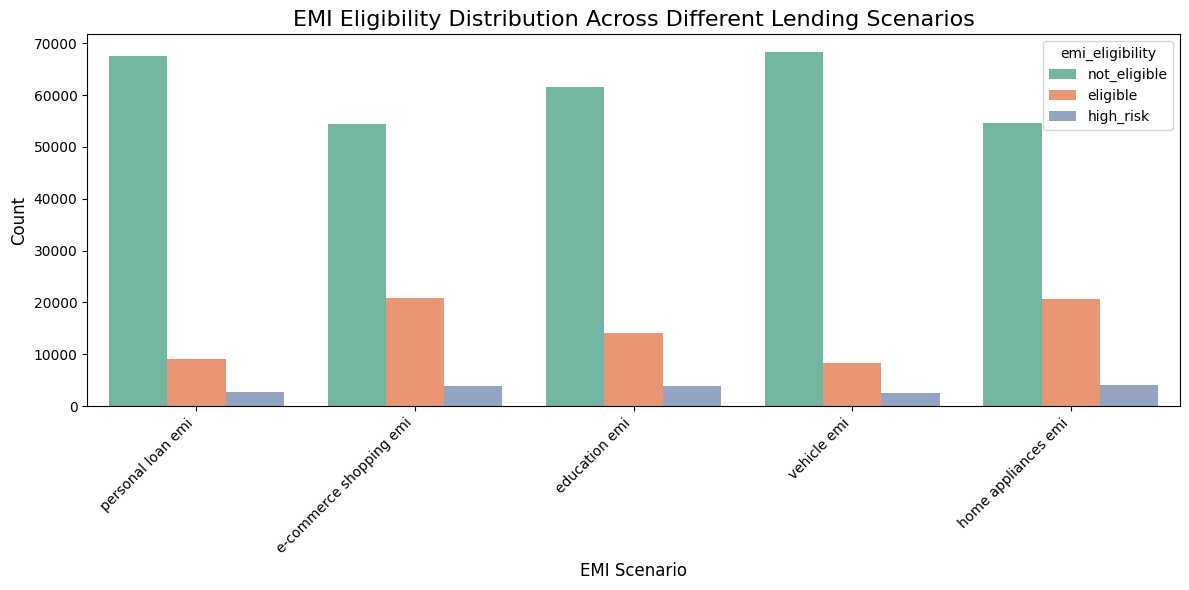

Plot saved successfully!


In [19]:
# Plotting the EMI eligibility distribution for all EMI scenarios on the same plot
plt.figure(figsize=(12, 6))
sns.countplot(
    x='emi_scenario', 
    hue='emi_eligibility',  # Use hue to differentiate by eligibility
    data=combined_data,  # Use the processed data
    palette="Set2"
)

# Set plot title and labels
plt.title("EMI Eligibility Distribution Across Different Lending Scenarios", fontsize=16)
plt.xlabel("EMI Scenario", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45, ha="right")  # Rotate x labels for better readability
plt.tight_layout()
plt.show()

# Save the plot
# plt.savefig(os.path.join(output_dir, "emi_eligibility_distribution_all_scenarios.png"))
# plt.close()  # Close the plot to avoid memory issues

print("Plot saved successfully!")

C:\Users\haris\AppData\Local\Temp\ipykernel_6500\935348001.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="emi_eligibility", y=column, data=combined_data, palette="Set2")
C:\Users\haris\AppData\Local\Temp\ipykernel_6500\935348001.py:15: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()
C:\Users\haris\AppData\Local\Temp\ipykernel_6500\935348001.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="emi_eligibility", y=column, data=combined_data, palette="Set2")
C:\Users\haris\AppData\Local\Temp\ipykernel_6500\935348001.py:15: UserWarning: Tight layout not applied. tight_layout cannot ma

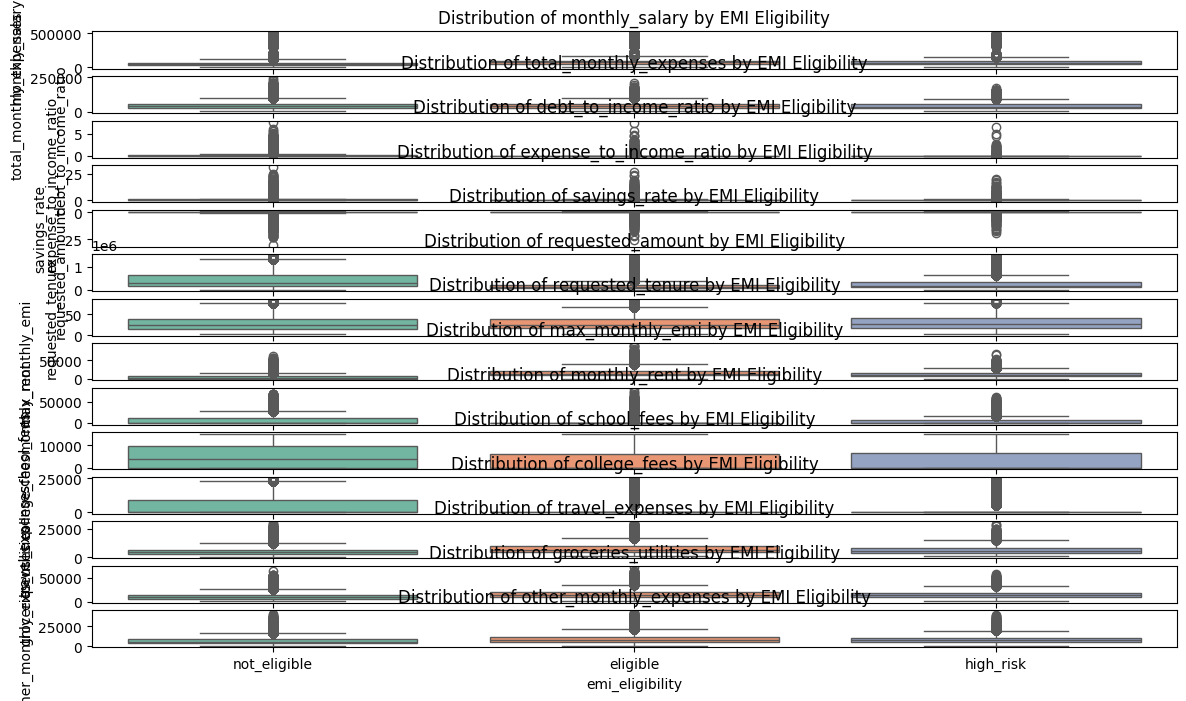

Combined plot saved successfully!


In [20]:
financial_columns= [
                        "monthly_salary", "total_monthly_expenses", "debt_to_income_ratio", "expense_to_income_ratio", 
                        "savings_rate", "requested_amount", "requested_tenure", "max_monthly_emi", "monthly_rent",
                        "school_fees", "college_fees", "travel_expenses", "groceries_utilities", "other_monthly_expenses"
                    ]

# Create a figure and axis to combine all the boxplots
plt.figure(figsize=(14, 8))

# Loop over each financial column and plot a boxplot on the same axes
for i, column in enumerate(financial_columns):
    plt.subplot(len(financial_columns), 1, i + 1)  # Create a subplot for each financial column
    sns.boxplot(x="emi_eligibility", y=column, data=combined_data, palette="Set2")
    plt.title(f"Distribution of {column} by EMI Eligibility")
    plt.tight_layout()
plt.show()
# Save the combined plot
# plt.savefig(os.path.join(output_dir, "combined_financial_variable_by_emi_eligibility.png"))
# plt.close()  # Close the plot to avoid memory issues

print("Combined plot saved successfully!")

In [ ]:
for column in financial_columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x="emi_eligibility", y=column, data=combined_data)
    plt.title(f"Distribution of {column} by EMI Eligibility")
    plt.tight_layout()
    plt.show()
    # plt.savefig(os.path.join(output_dir, f"financial_variable_{column}_by_emi_eligibility.png"))
    # plt.close()

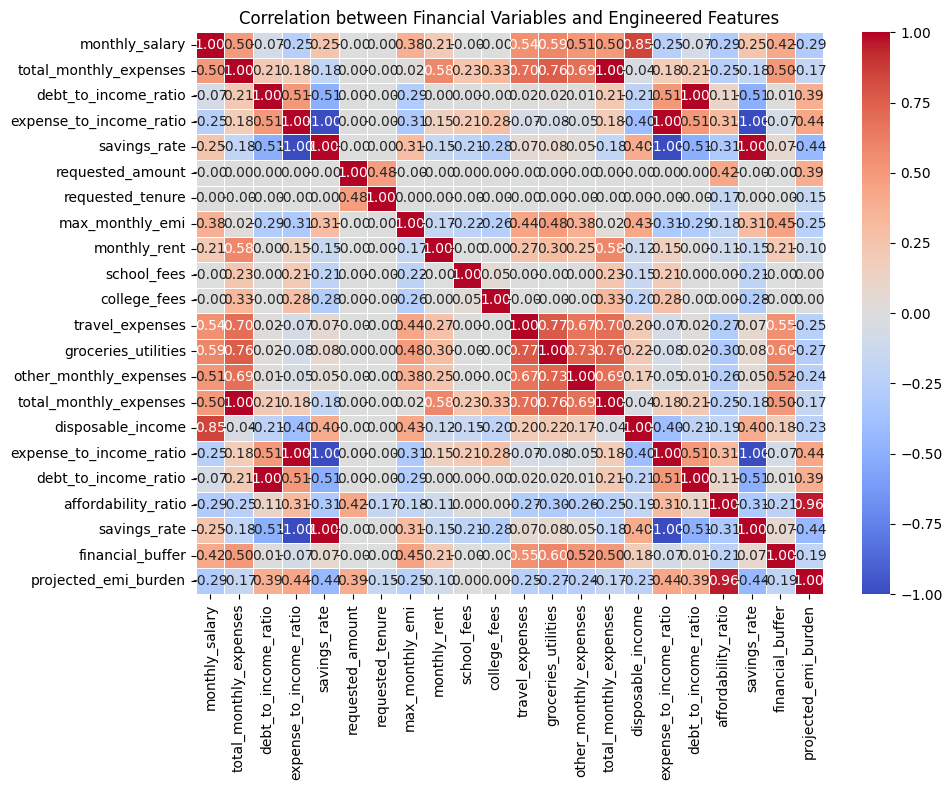

In [22]:
financial_data = combined_data[financial_columns + engineered_features]
correlation_matrix = financial_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation between Financial Variables and Engineered Features")
plt.tight_layout()
# plt.savefig(os.path.join(output_dir, "financial_and_engineered_features_correlation_heatmap.png"))
# plt.close()
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(combined_data[combined_data['emi_eligibility'] == 'eligible']['age'], color="blue", kde=True, label="Eligible")
sns.histplot(combined_data[combined_data['emi_eligibility'] == 'not_eligible']['age'], color="red", kde=True, label="Not Eligible")
plt.legend()
plt.title('Age Distribution by EMI Eligibility')
plt.tight_layout()
# plt.savefig(os.path.join(output_dir, "age_distribution_by_emi_eligibility.png"))
# plt.close()
plt.show()

# Gender Distribution by EMI Eligibility
plt.figure(figsize=(8, 6))
sns.countplot(x="gender", hue="emi_eligibility", data=combined_data)
plt.title('EMI Eligibility by Gender')
plt.tight_layout()
# plt.savefig(os.path.join(output_dir, "emi_eligibility_by_gender.png"))
# plt.close()
plt.show()

# Marital Status vs EMI Eligibility
plt.figure(figsize=(8, 6))
sns.countplot(x="marital_status", hue="emi_eligibility", data=combined_data)
plt.title('EMI Eligibility by Marital Status')
plt.tight_layout()
# plt.savefig(os.path.join(output_dir, "emi_eligibility_by_marital_status.png"))
# plt.close()
plt.show()

# Family Size and EMI Eligibility
plt.figure(figsize=(8, 6))
sns.boxplot(x="emi_eligibility", y="family_size", data=combined_data)
plt.title('Family Size vs EMI Eligibility')
plt.tight_layout()
# plt.savefig(os.path.join(output_dir, "family_size_vs_emi_eligibility.png"))
# plt.close()
plt.show()

# Existing loans and EMI eligibility
plt.figure(figsize=(8, 6))
sns.countplot(x="existing_loans", hue="emi_eligibility", data=combined_data)
plt.title('EMI Eligibility by Existing Loans')
plt.tight_layout()
# plt.savefig(os.path.join(output_dir, "emi_eligibility_by_existing_loans.png"))
# plt.close()
plt.show()

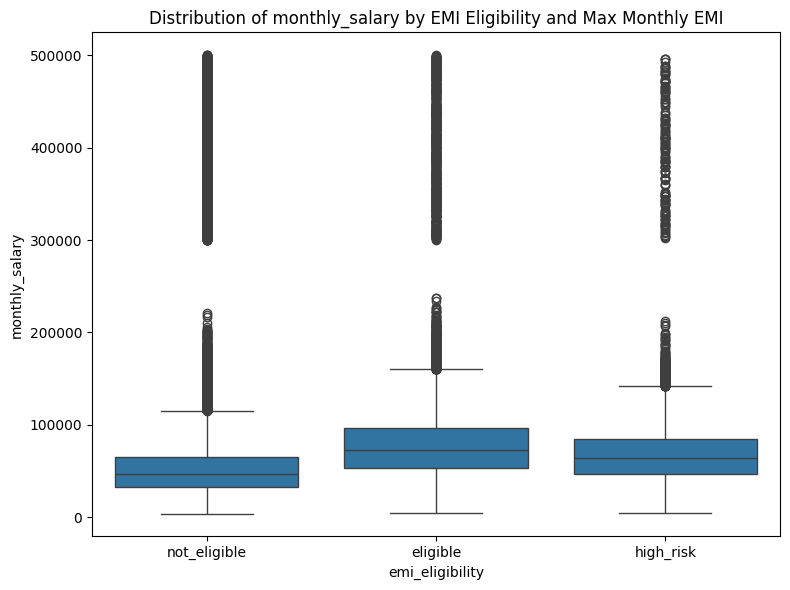

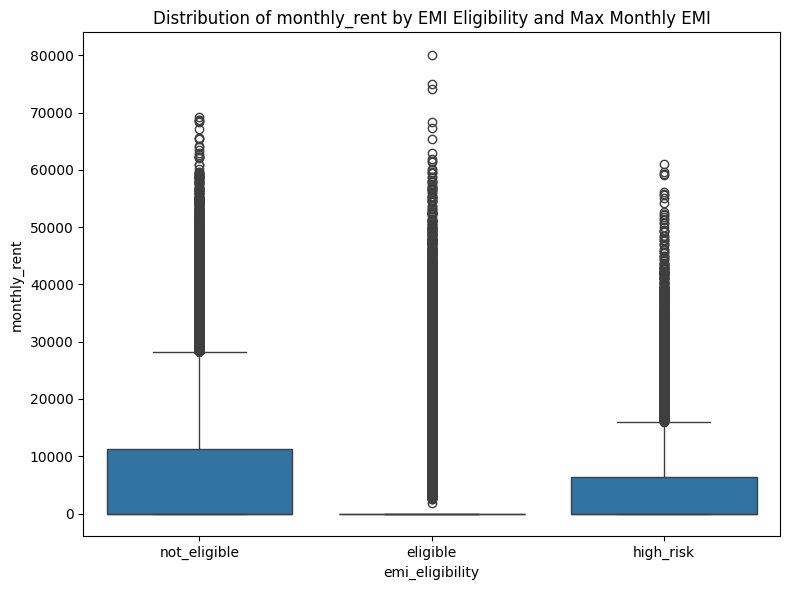

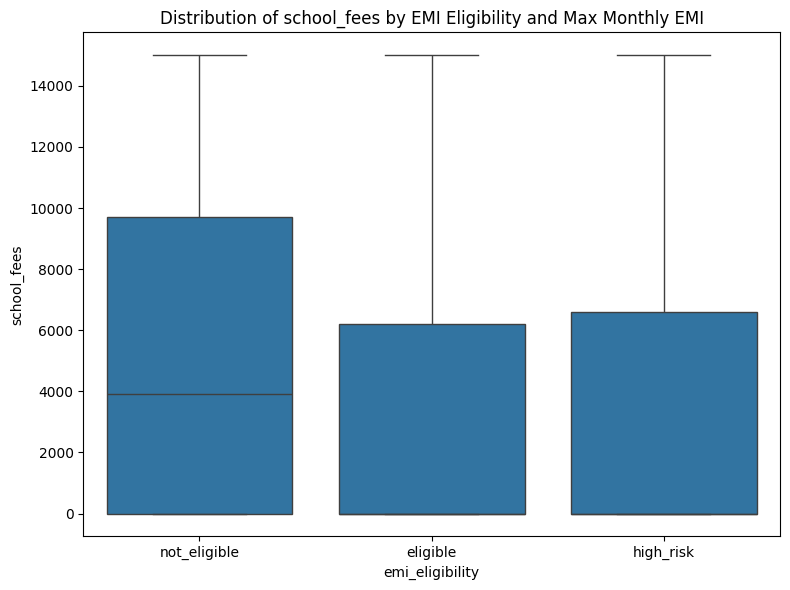

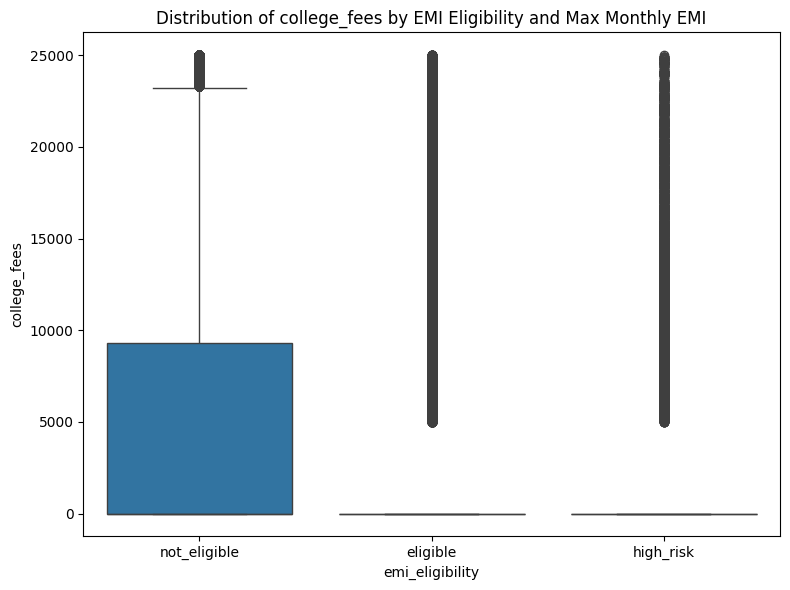

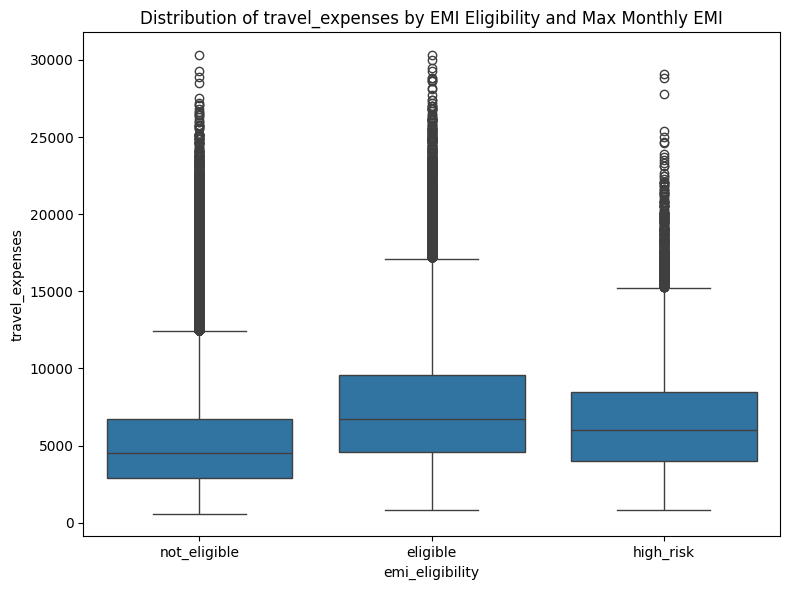

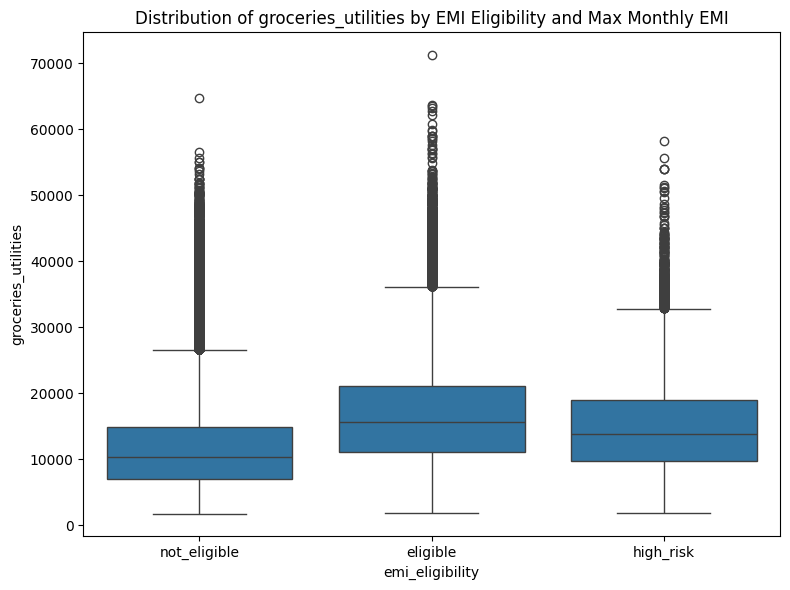

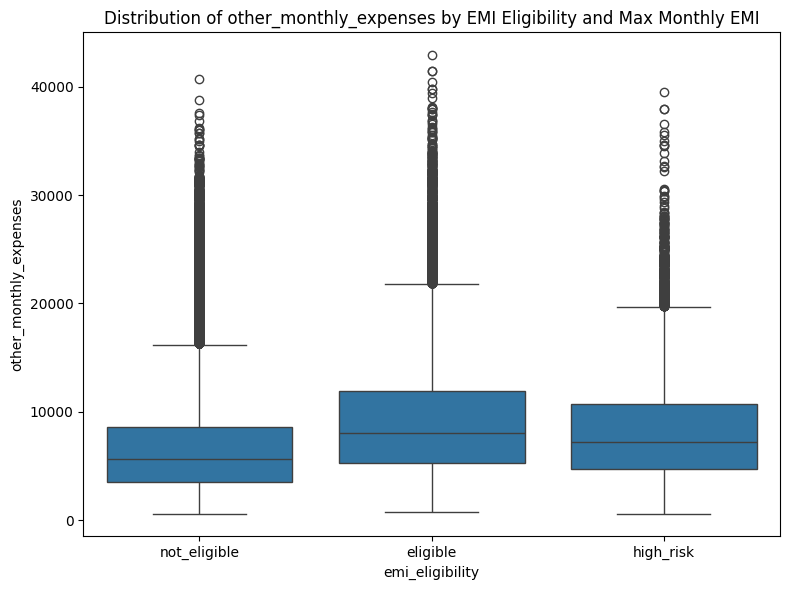

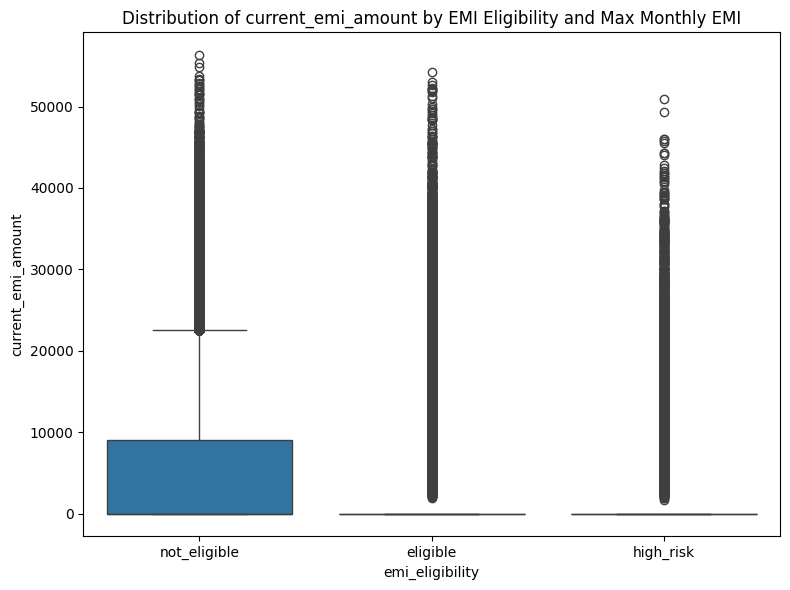

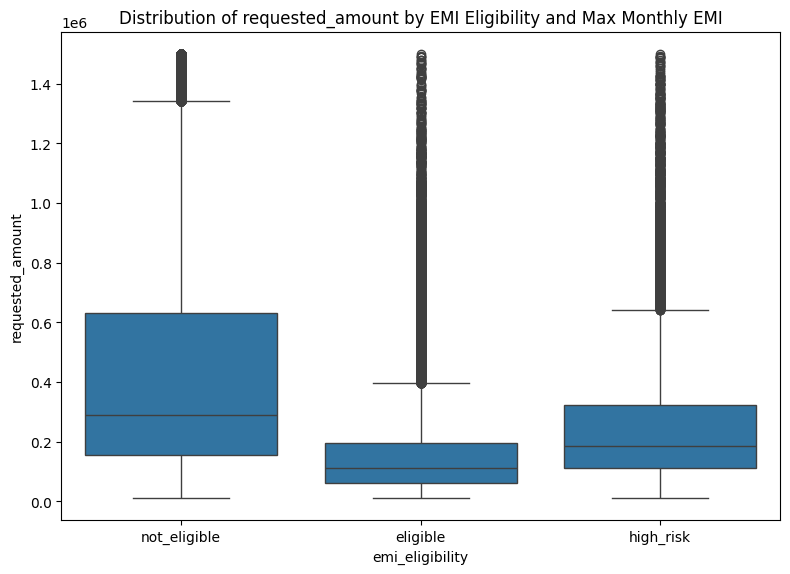

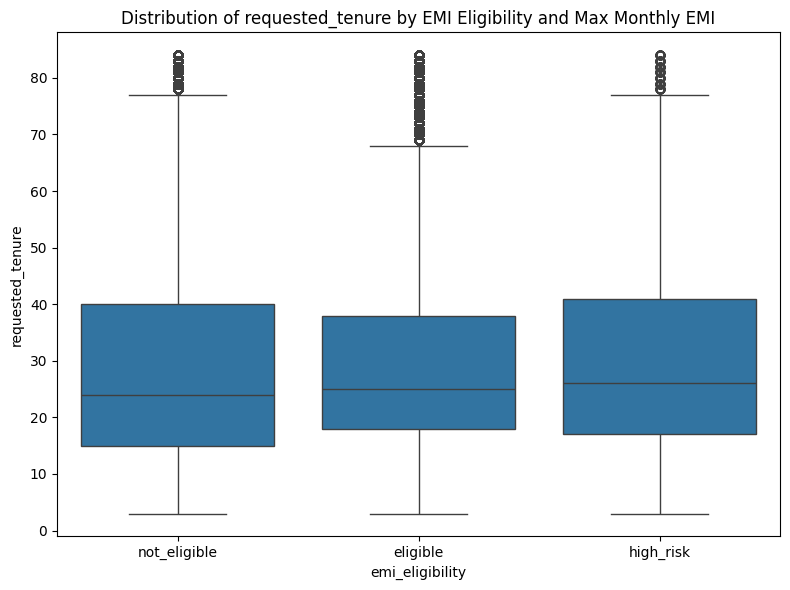

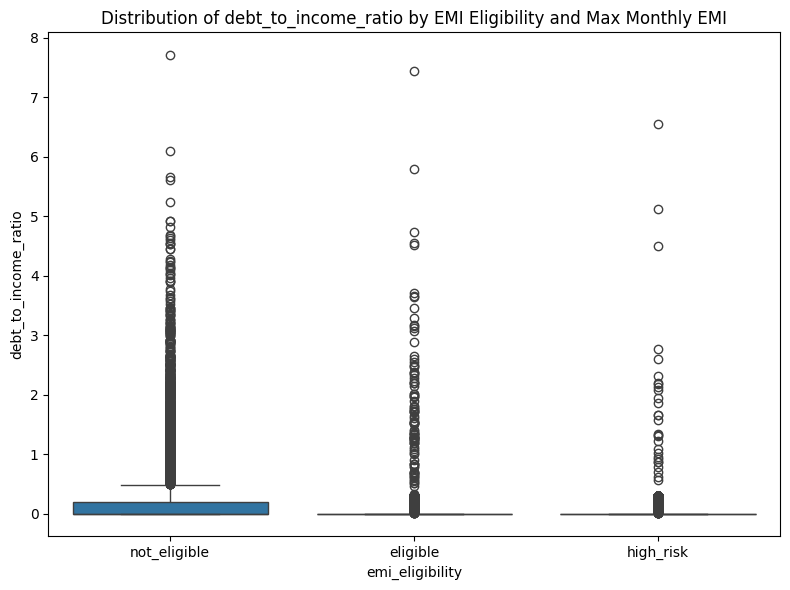

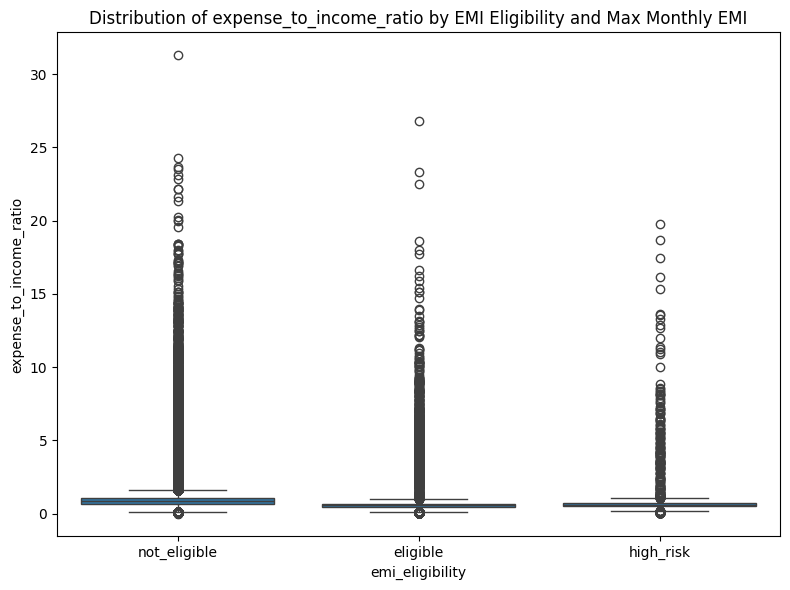

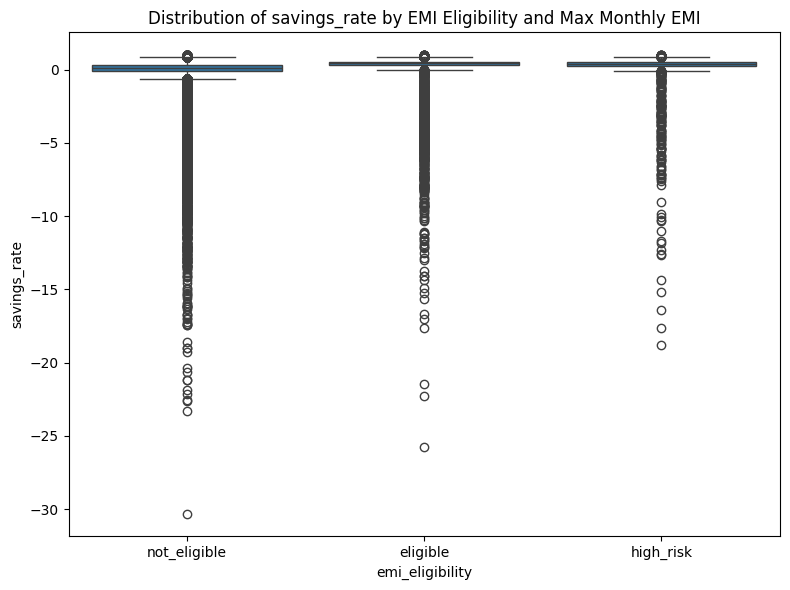

In [25]:
max_emi_columns = [
    'monthly_salary', 'monthly_rent', 'school_fees', 'college_fees', 'travel_expenses', 
    'groceries_utilities', 'other_monthly_expenses', 'current_emi_amount', 'requested_amount', 
    'requested_tenure', 'debt_to_income_ratio', 'expense_to_income_ratio', 'savings_rate'
]

for column in max_emi_columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x="emi_eligibility", y=column, data=combined_data)
    plt.title(f"Distribution of {column} by EMI Eligibility and Max Monthly EMI")
    plt.tight_layout()
    # plt.savefig(os.path.join(output_dir, f"max_emi_vs_{column}.png"))
    # plt.close()
    plt.show()